# 📊 Visualização de Dados com Matplotlib & Seaborn

Este notebook faz parte do meu portfólio de Data Science (**Dia 3 / Fase 1 — Python Basics**).

Nos dias anteriores exploramos **Pandas** (Dia 1) para manipulação de dados e **NumPy** (Dia 2) para
computação numérica. Hoje damos o próximo passo natural: **transformar dados em gráficos**.

Visualização não é apenas "deixar bonito" — é uma ferramenta de *raciocínio*. Um bom gráfico revela
padrões, tendências e anomalias que ficariam escondidos em uma tabela de números. Para quem vem da
**Linguística**, a analogia é direta: assim como uma boa transcrição fonética torna visível a estrutura
da fala, uma boa visualização torna visível a estrutura dos dados.

> 🎓 **Contexto aplicado:** ao longo do notebook conecto os exemplos a cenários de **NLP e ensino de
> línguas** — por exemplo, pensar em comprimentos de palavras, frequências e escores de alunos como
> variáveis que podem ser visualizadas.

## 🎯 Objetivos de Aprendizado

Ao final deste notebook, você será capaz de:

1. Entender a **anatomia de uma figura** no Matplotlib (`Figure`, `Axes`, `subplots`).
2. Criar os gráficos fundamentais: **linha, barra, dispersão (scatter) e histograma**.
3. Usar o **Seaborn** para gráficos estatísticos de alto nível com pouco código.
4. Produzir **boxplot, violin plot, heatmap e pairplot** para análise de distribuições e correlações.
5. Trabalhar com **gráficos categóricos** (`barplot`, `countplot`).
6. **Combinar** Matplotlib e Seaborn no mesmo eixo.
7. **Customizar** cores, estilos, títulos e anotações.
8. **Salvar figuras** em disco em alta resolução.
9. Aplicar tudo em um **estudo de caso** com narrativa voltada a linguagem/educação.

⚠️ **Regra de dados:** usamos **apenas datasets reais e públicos** embutidos no Seaborn e no
scikit-learn. Nenhum dado é inventado.

In [1]:
# Core scientific & visualization stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# Reproducibility for any random operation
RNG = np.random.default_rng(42)

# Seaborn global theme: clean grid, readable fonts
sns.set_theme(style="whitegrid", context="notebook")

# Default figure size for Matplotlib
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

print(f"NumPy version:      {np.__version__}")
print(f"Pandas version:     {pd.__version__}")
print(f"Matplotlib version: {mpl.__version__}")
print(f"Seaborn version:    {sns.__version__}")

NumPy version:      1.26.4
Pandas version:     2.2.3
Matplotlib version: 3.9.2
Seaborn version:    0.13.2


## 1. A Anatomia de uma Figura no Matplotlib

O Matplotlib é a biblioteca base sobre a qual quase todo o ecossistema de visualização do Python é
construído (inclusive o Seaborn). Dois objetos são centrais:

- **`Figure`** — a "moldura" ou o *canvas* inteiro. Pode conter um ou vários gráficos.
- **`Axes`** — cada gráfico individual (com seus eixos x/y, título, legenda). **Não confundir** `Axes`
  (o gráfico) com `axis` (um único eixo, x ou y).

Existem duas interfaces:
- **Interface `pyplot`** (`plt.plot(...)`) — rápida, boa para gráficos simples.
- **Interface orientada a objetos** (`fig, ax = plt.subplots()`) — explícita e recomendada para
  gráficos complexos. Usaremos majoritariamente esta.

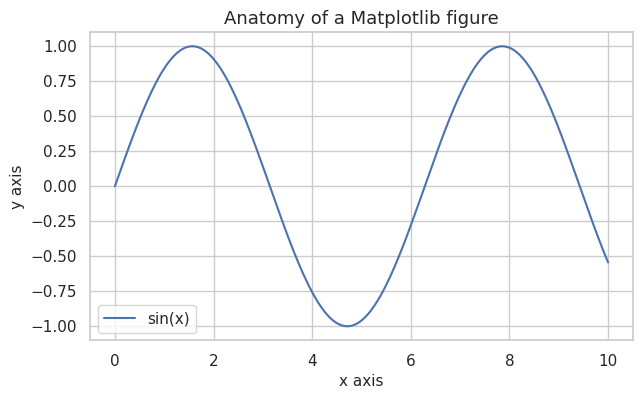

In [2]:
# The object-oriented way: create a Figure and one Axes explicitly
fig, ax = plt.subplots(figsize=(7, 4))

x = np.linspace(0, 10, 200)          # 200 evenly spaced points from 0 to 10
ax.plot(x, np.sin(x), label="sin(x)")

ax.set_title("Anatomy of a Matplotlib figure")
ax.set_xlabel("x axis")
ax.set_ylabel("y axis")
ax.legend()

plt.show()

### 1.1 Múltiplos eixos (subplots)

`plt.subplots(nrows, ncols)` cria uma grade de eixos. O objeto retornado `axes` é um array NumPy —
podemos indexá-lo (`axes[0, 1]`) ou "achatá-lo" com `.flatten()` para iterar.

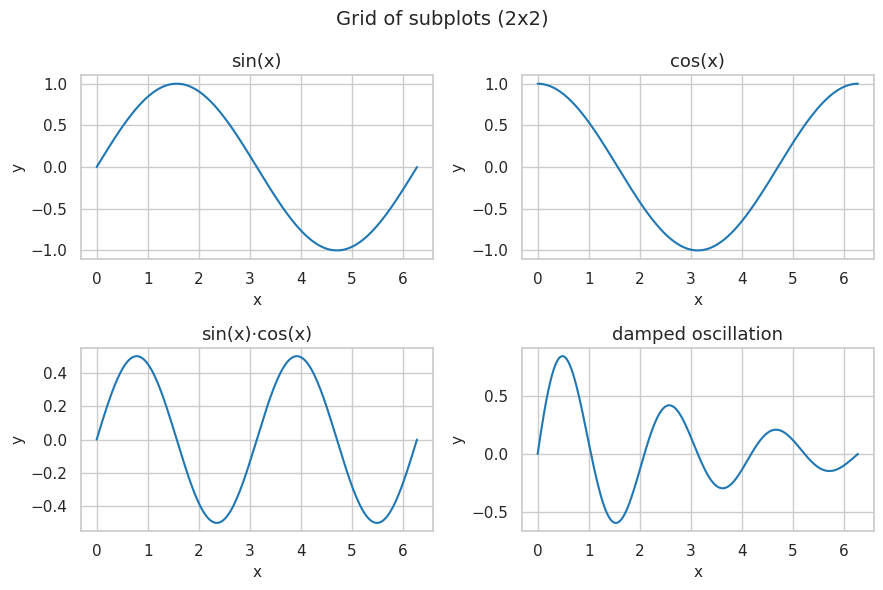

In [3]:
# A 2x2 grid of subplots sharing a common style
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(9, 6))

x = np.linspace(0, 2 * np.pi, 200)
functions = [
    (np.sin(x), "sin(x)"),
    (np.cos(x), "cos(x)"),
    (np.sin(x) * np.cos(x), "sin(x)·cos(x)"),
    (np.exp(-x / 3) * np.sin(3 * x), "damped oscillation"),
]

# axes.flatten() lets us iterate over the 2D grid as a 1D sequence
for ax, (y, title) in zip(axes.flatten(), functions):
    ax.plot(x, y, color="tab:blue")
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

fig.suptitle("Grid of subplots (2x2)", fontsize=14)
fig.tight_layout()   # avoids overlapping labels
plt.show()

## 2. Carregando um Dataset Real

Vamos usar o dataset **`tips`** embutido no Seaborn. Ele registra gorjetas em um restaurante e é
excelente para praticar visualização porque mistura variáveis **numéricas** (`total_bill`, `tip`) e
**categóricas** (`day`, `time`, `sex`, `smoker`).

> 🎓 **Ponte com linguística/educação:** pense neste dataset como um *corpus* — cada linha é uma
> "observação" e cada coluna é uma "variável". A mesma lógica vale para um corpus de textos onde as
> colunas poderiam ser *número de palavras*, *nível do aluno*, *nota na redação* etc.

In [4]:
# Load a real, public dataset shipped with seaborn
tips = sns.load_dataset("tips")

# Quick structural inspection (habits from Day 1 - pandas)
print("Shape:", tips.shape)
print("\nColumn dtypes:")
print(tips.dtypes)
tips.head()

Shape: (244, 7)

Column dtypes:
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [5]:
# Statistical summary of the numeric columns
tips.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


## 3. Gráficos Fundamentais com Matplotlib

### 3.1 Gráfico de Linha (Line Plot)

Gráficos de linha são ideais para mostrar a **evolução de um valor** ao longo de uma sequência
ordenada (tempo, posição, etapas). Aqui simulamos uma "curva de aprendizado" agregando a gorjeta
média por tamanho de grupo (`size`).

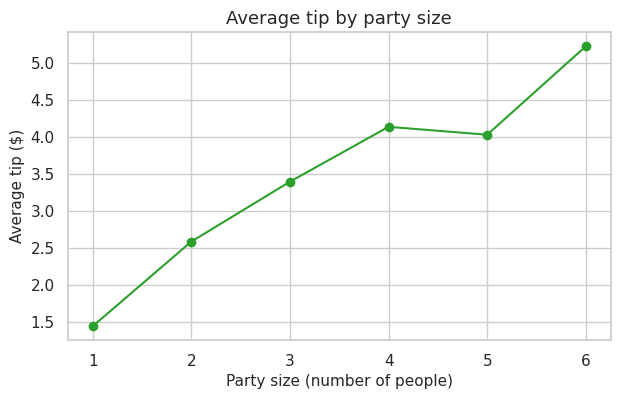

In [6]:
# Aggregate: mean tip per party size (ordered numeric x-axis)
tip_by_size = tips.groupby("size")["tip"].mean()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(tip_by_size.index, tip_by_size.values,
        marker="o", linestyle="-", color="tab:green")

ax.set_title("Average tip by party size")
ax.set_xlabel("Party size (number of people)")
ax.set_ylabel("Average tip ($)")
plt.show()

### 3.2 Gráfico de Barras (Bar Chart)

Barras comparam quantidades entre **categorias discretas**. Abaixo, a conta média (`total_bill`) por
dia da semana.

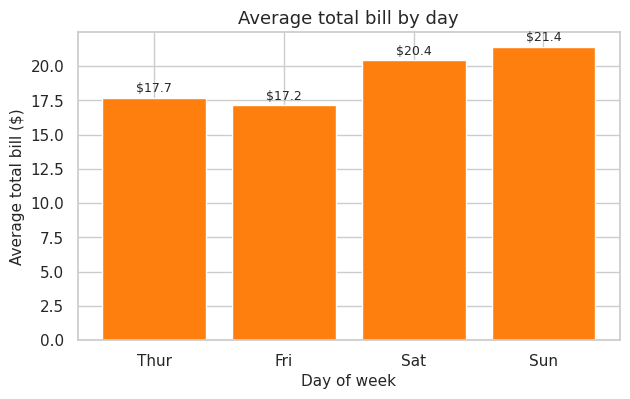

In [7]:
# Mean total bill per day
bill_by_day = tips.groupby("day", observed=True)["total_bill"].mean()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(bill_by_day.index.astype(str), bill_by_day.values, color="tab:orange")

# Annotate each bar with its value
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.2,
            f"${height:.1f}", ha="center", va="bottom", fontsize=9)

ax.set_title("Average total bill by day")
ax.set_xlabel("Day of week")
ax.set_ylabel("Average total bill ($)")
plt.show()

### 3.3 Gráfico de Dispersão (Scatter Plot)

Dispersão revela a **relação entre duas variáveis numéricas**. Esperamos que contas maiores gerem
gorjetas maiores — ou seja, uma correlação positiva.

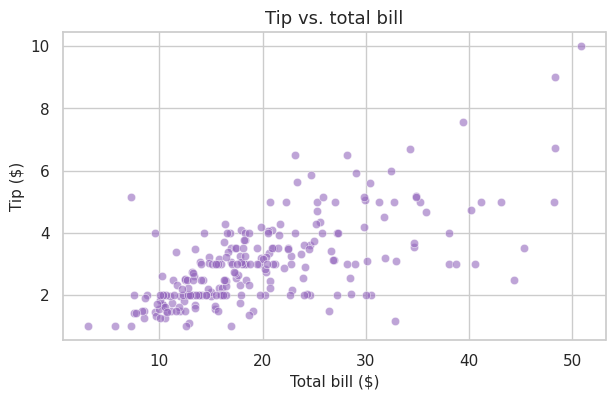

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(tips["total_bill"], tips["tip"],
           alpha=0.6, c="tab:purple", edgecolors="white", linewidth=0.5)

ax.set_title("Tip vs. total bill")
ax.set_xlabel("Total bill ($)")
ax.set_ylabel("Tip ($)")
plt.show()

### 3.4 Histograma (Histogram)

Histogramas mostram a **distribuição** de uma única variável numérica, agrupando os valores em
"caixas" (*bins*). É a forma mais direta de ver assimetria, concentração e outliers.

> 🎓 Em NLP, o histograma é onipresente: distribuição de comprimentos de sentenças, de frequências de
> palavras (lei de Zipf!), de escores de legibilidade etc.

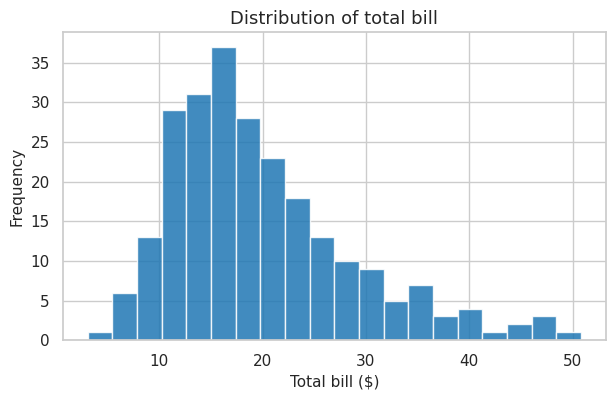

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(tips["total_bill"], bins=20, color="tab:blue",
        edgecolor="white", alpha=0.85)

ax.set_title("Distribution of total bill")
ax.set_xlabel("Total bill ($)")
ax.set_ylabel("Frequency")
plt.show()

## 4. Introdução ao Seaborn

O **Seaborn** é construído sobre o Matplotlib, mas oferece:
- Funções de **alto nível** que produzem gráficos estatísticos complexos com uma linha.
- Integração nativa com **DataFrames do Pandas** (você passa colunas por nome).
- **Temas e paletas** esteticamente agradáveis por padrão.

A API do Seaborn se divide em dois grandes grupos:
- **Funções em nível de figura** (`relplot`, `catplot`, `displot`, `pairplot`) — criam a figura inteira.
- **Funções em nível de eixo** (`scatterplot`, `boxplot`, `histplot`...) — desenham em um `Axes`
  existente, permitindo combinar com Matplotlib.

### 4.1 Temas do Seaborn

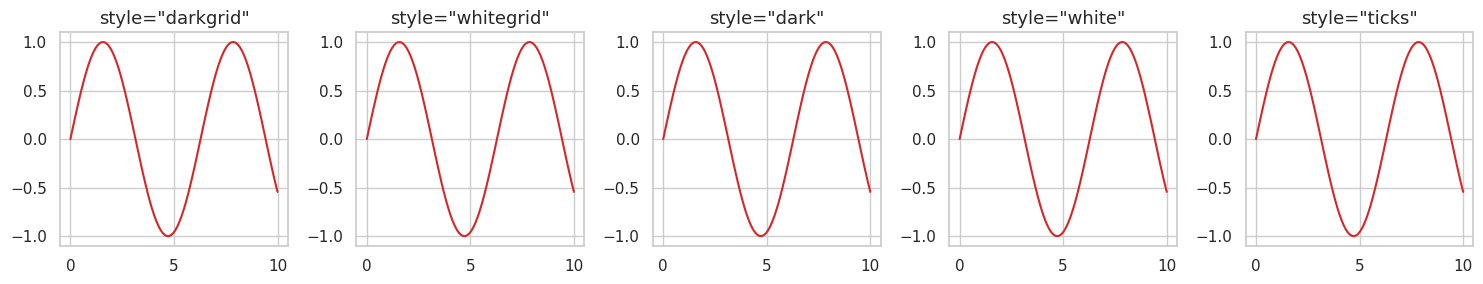

In [10]:
# Demonstrate the 5 built-in seaborn styles
styles = ["darkgrid", "whitegrid", "dark", "white", "ticks"]

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
x = np.linspace(0, 10, 100)

for ax, style in zip(axes, styles):
    with sns.axes_style(style):   # temporary style context
        ax.plot(x, np.sin(x), color="tab:red")
        ax.set_title(f'style="{style}"')

fig.tight_layout()
plt.show()

# Reset to our working theme
sns.set_theme(style="whitegrid", context="notebook")

### 4.2 O poder do `hue`: adicionando uma terceira dimensão

O grande diferencial do Seaborn é mapear variáveis para propriedades visuais (**cor**, **tamanho**,
**estilo**) automaticamente através dos parâmetros `hue`, `size` e `style`.

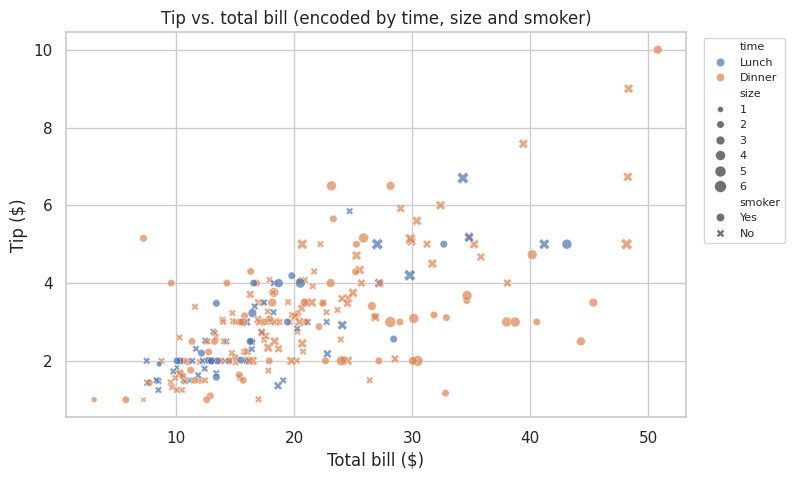

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

# hue -> color by category, size -> point size by party size, style -> marker by time
sns.scatterplot(
    data=tips, x="total_bill", y="tip",
    hue="time", size="size", style="smoker",
    alpha=0.7, ax=ax,
)

ax.set_title("Tip vs. total bill (encoded by time, size and smoker)")
ax.set_xlabel("Total bill ($)")
ax.set_ylabel("Tip ($)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.show()

### 4.3 Regressão visual com `regplot`

O Seaborn também ajusta e desenha uma **reta de regressão** com intervalo de confiança, útil para
confirmar visualmente uma tendência linear.

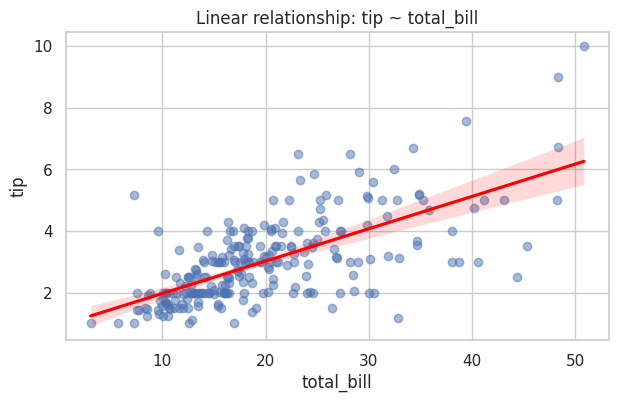

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.regplot(data=tips, x="total_bill", y="tip",
            scatter_kws={"alpha": 0.5}, line_kws={"color": "red"}, ax=ax)
ax.set_title("Linear relationship: tip ~ total_bill")
plt.show()

## 5. Gráficos Estatísticos com Seaborn

### 5.1 Boxplot

O **boxplot** resume uma distribuição em 5 números: mínimo, 1º quartil (Q1), mediana, 3º quartil (Q3)
e máximo — e marca *outliers* como pontos isolados. É perfeito para **comparar distribuições entre
categorias**.

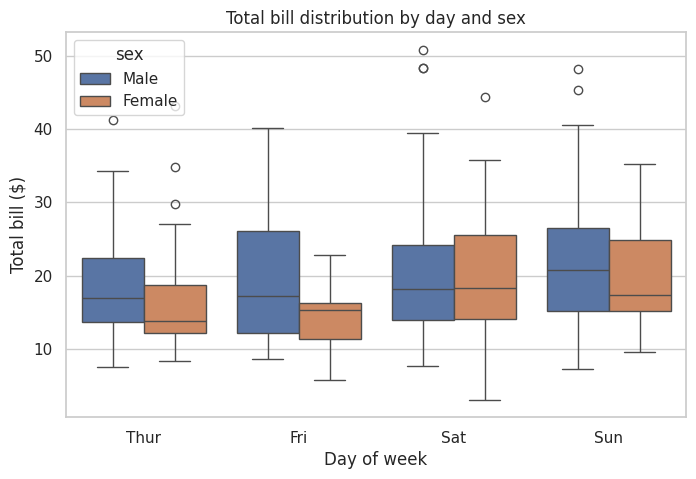

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=tips, x="day", y="total_bill", hue="sex", ax=ax)
ax.set_title("Total bill distribution by day and sex")
ax.set_xlabel("Day of week")
ax.set_ylabel("Total bill ($)")
plt.show()

### 5.2 Violin Plot

O **violin plot** combina o boxplot com uma **estimativa de densidade** (KDE). Além dos quartis, ele
mostra o *formato* da distribuição — se é bimodal, assimétrica etc.

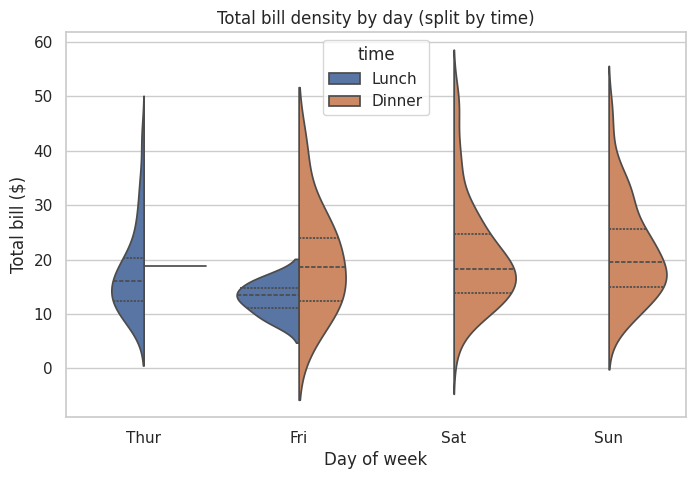

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(data=tips, x="day", y="total_bill", hue="time",
               split=True, inner="quart", ax=ax)
ax.set_title("Total bill density by day (split by time)")
ax.set_xlabel("Day of week")
ax.set_ylabel("Total bill ($)")
plt.show()

### 5.3 Heatmap (Mapa de Calor)

Um **heatmap** representa valores de uma matriz por intensidade de cor. O uso mais comum é visualizar
uma **matriz de correlação** — enxergar de relance quais variáveis andam juntas.

> 🎓 Em análise de corpora, heatmaps são ótimos para matrizes de coocorrência de palavras ou
> similaridade entre documentos.

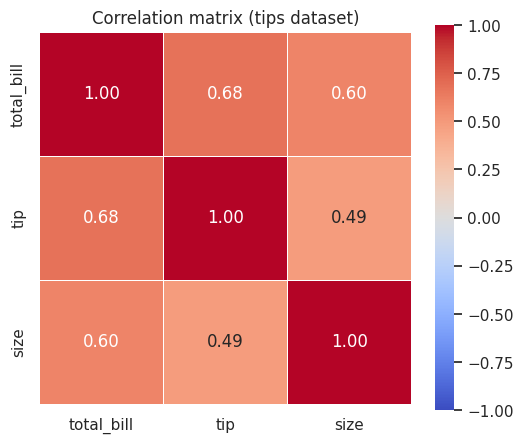

In [15]:
# Correlation matrix of the numeric columns
corr = tips.select_dtypes("number").corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1,
            square=True, linewidths=0.5, fmt=".2f", ax=ax)
ax.set_title("Correlation matrix (tips dataset)")
plt.show()

### 5.4 Pairplot

O **pairplot** desenha, de uma só vez, todos os gráficos de dispersão par-a-par entre as variáveis
numéricas, com histogramas/KDE na diagonal. É uma ferramenta de **exploração inicial** poderosíssima.

Aqui trocamos para o dataset **`penguins`**, que tem grupos (`species`) bem separados — ideal para
mostrar como o `hue` revela *clusters* naturais.

Penguins shape (after dropna): (333, 7)


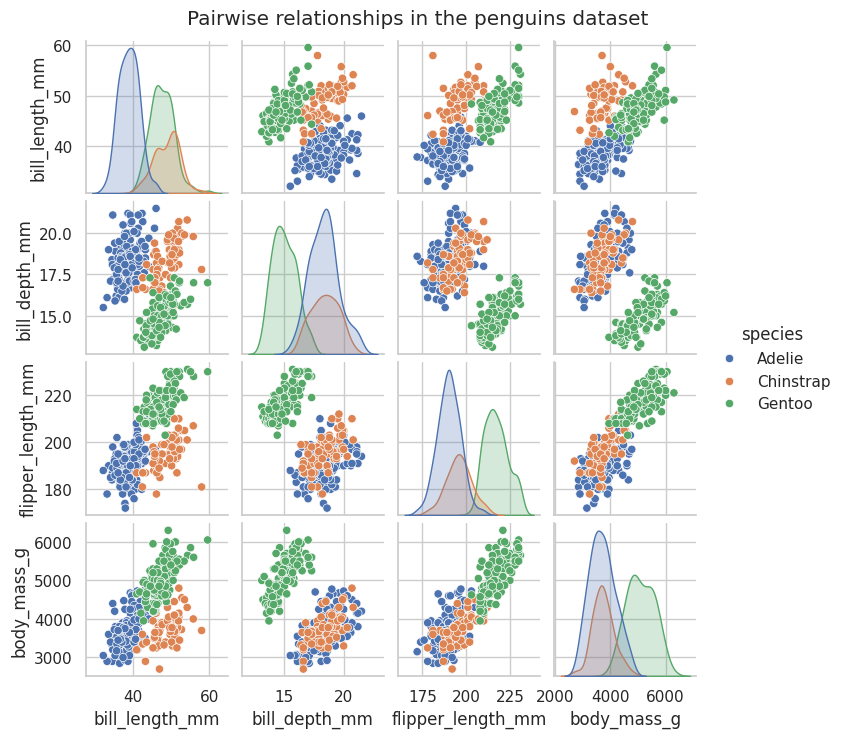

In [16]:
# Load penguins and drop rows with missing values for a clean pairplot
penguins = sns.load_dataset("penguins").dropna()
print("Penguins shape (after dropna):", penguins.shape)

# pairplot is a figure-level function: it returns a PairGrid, not an Axes
grid = sns.pairplot(penguins, hue="species", diag_kind="kde", height=1.8)
grid.figure.suptitle("Pairwise relationships in the penguins dataset", y=1.02)
plt.show()

## 6. Gráficos Categóricos

### 6.1 Countplot

O `countplot` conta as ocorrências de cada categoria — é um "histograma para variáveis categóricas".

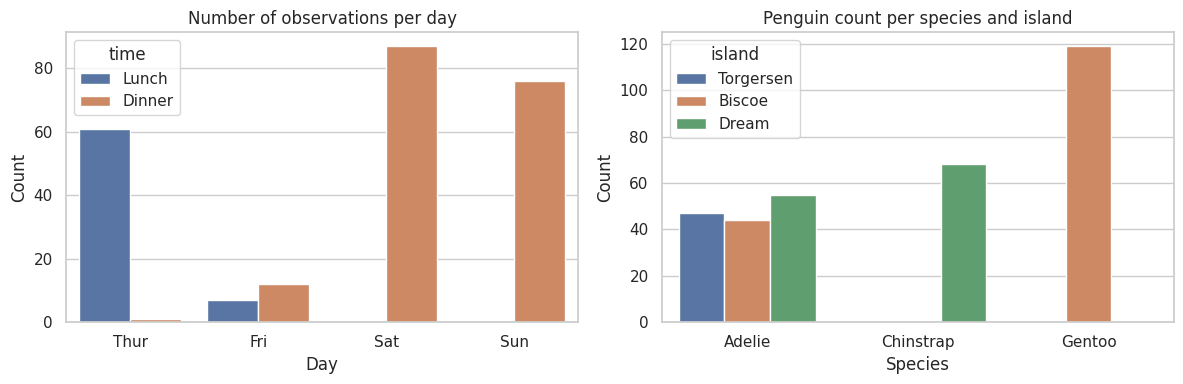

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=tips, x="day", hue="time", ax=axes[0])
axes[0].set_title("Number of observations per day")
axes[0].set_xlabel("Day")
axes[0].set_ylabel("Count")

sns.countplot(data=penguins, x="species", hue="island", ax=axes[1])
axes[1].set_title("Penguin count per species and island")
axes[1].set_xlabel("Species")
axes[1].set_ylabel("Count")

fig.tight_layout()
plt.show()

### 6.2 Barplot (com estimativa e intervalo de confiança)

Diferente do `countplot`, o `barplot` do Seaborn calcula uma **estatística agregada** (por padrão, a
**média**) de uma variável numérica por categoria e mostra a **barra de erro** (intervalo de
confiança via *bootstrap*).

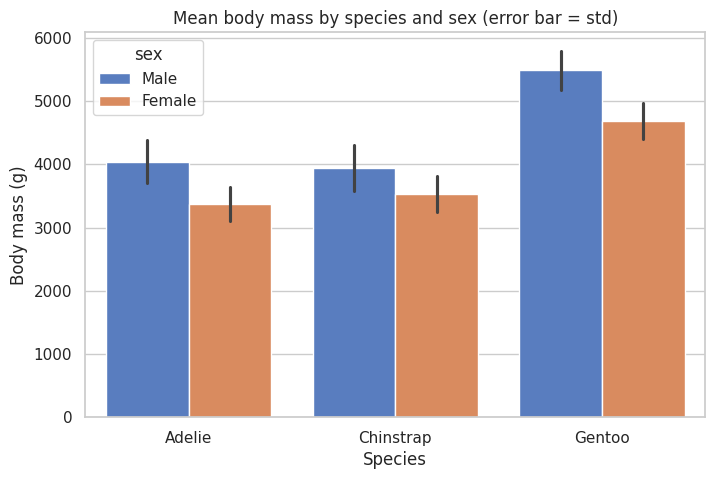

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=penguins, x="species", y="body_mass_g", hue="sex",
            errorbar="sd", palette="muted", ax=ax)
ax.set_title("Mean body mass by species and sex (error bar = std)")
ax.set_xlabel("Species")
ax.set_ylabel("Body mass (g)")
plt.show()

## 7. Combinando Matplotlib + Seaborn

Como o Seaborn desenha sobre eixos do Matplotlib, podemos **sobrepor camadas**: um `histplot` do
Seaborn e, por cima, uma linha de referência com Matplotlib puro (`axvline`).

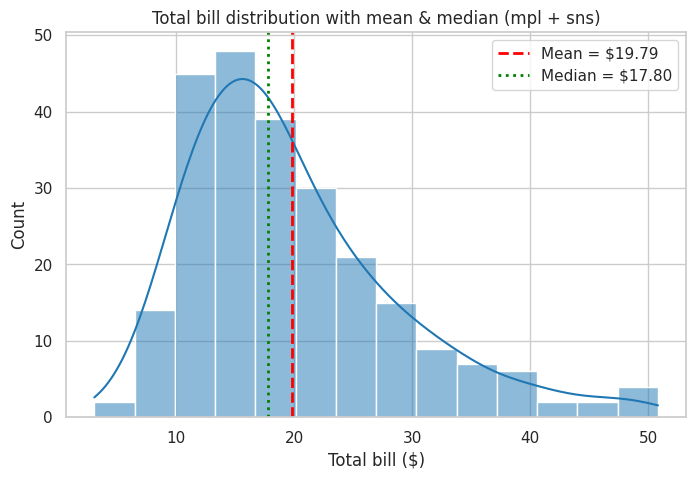

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))

# Seaborn layer: histogram + KDE
sns.histplot(data=tips, x="total_bill", kde=True, color="tab:blue", ax=ax)

# Matplotlib layer: vertical lines for mean and median
mean_bill = tips["total_bill"].mean()
median_bill = tips["total_bill"].median()
ax.axvline(mean_bill, color="red", linestyle="--", linewidth=2,
           label=f"Mean = ${mean_bill:.2f}")
ax.axvline(median_bill, color="green", linestyle=":", linewidth=2,
           label=f"Median = ${median_bill:.2f}")

ax.set_title("Total bill distribution with mean & median (mpl + sns)")
ax.set_xlabel("Total bill ($)")
ax.legend()
plt.show()

## 8. Customização: Cores, Estilos, Títulos e Anotações

Um gráfico de qualidade profissional comunica a mensagem **sem exigir esforço** do leitor. Abaixo
reunimos várias técnicas de customização em um único exemplo: paleta personalizada, anotação de um
ponto de interesse com seta, ajuste de limites e remoção de bordas (`despine`).

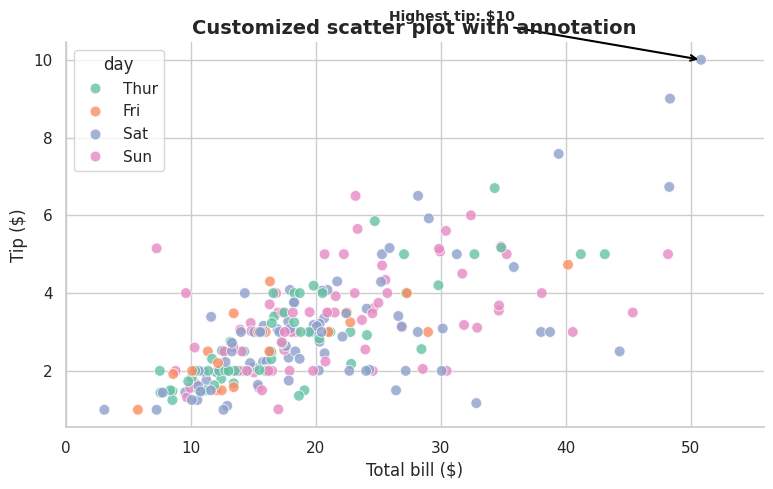

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.scatterplot(data=tips, x="total_bill", y="tip",
                hue="day", palette="Set2", s=60, alpha=0.8, ax=ax)

# Highlight the single most generous tip with an annotation arrow
top = tips.loc[tips["tip"].idxmax()]
ax.annotate(
    f"Highest tip: ${top['tip']:.0f}",
    xy=(top["total_bill"], top["tip"]),
    xytext=(top["total_bill"] - 25, top["tip"] + 1),
    arrowprops=dict(arrowstyle="->", color="black", lw=1.5),
    fontsize=10, fontweight="bold",
)

ax.set_title("Customized scatter plot with annotation", fontsize=14, fontweight="bold")
ax.set_xlabel("Total bill ($)")
ax.set_ylabel("Tip ($)")
ax.set_xlim(0, tips["total_bill"].max() + 5)
sns.despine(ax=ax)   # remove top and right spines
plt.show()

### 8.1 Paletas de Cores

A escolha da paleta importa: **qualitativa** para categorias, **sequencial** para valores ordenados e
**divergente** para dados com um ponto central (ex.: correlações positivas vs. negativas).

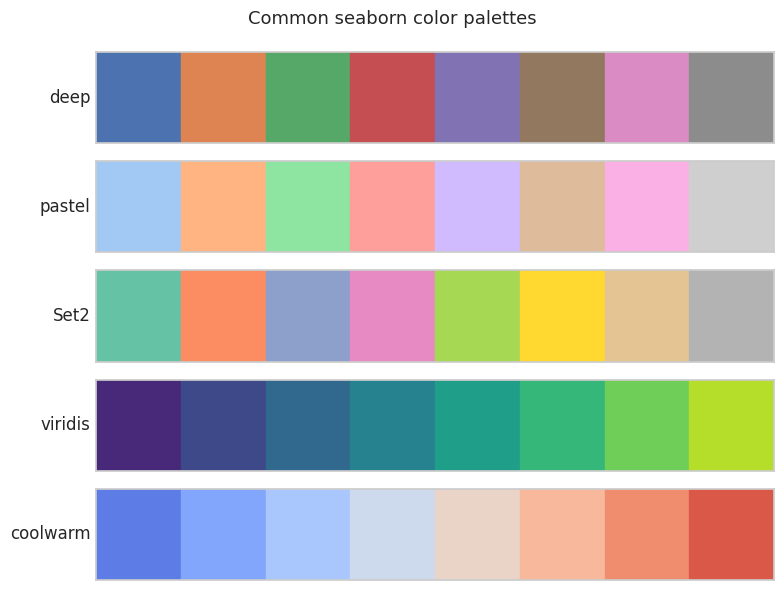

In [21]:
palettes = ["deep", "pastel", "Set2", "viridis", "coolwarm"]

fig, axes = plt.subplots(len(palettes), 1, figsize=(8, 6))
for ax, pal in zip(axes, palettes):
    sns.palplot  # noqa (illustrative)
    colors = sns.color_palette(pal, 8)
    for i, c in enumerate(colors):
        ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=c))
    ax.set_xlim(0, 8)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_ylabel(pal, rotation=0, ha="right", va="center")

fig.suptitle("Common seaborn color palettes", fontsize=13)
fig.tight_layout()
plt.show()

## 9. Salvando Figuras

Para relatórios, artigos ou o próprio README do portfólio, salvamos as figuras em disco. Dicas:
- Use **`dpi=300`** para qualidade de impressão.
- **`bbox_inches="tight"`** remove margens em branco excessivas.
- Formatos: `.png` (raster, geral), `.svg`/`.pdf` (vetorial, escalável sem perda).

In [22]:
from pathlib import Path

# Save into a local 'figures' folder next to the notebook
out_dir = Path("figures")
out_dir.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=tips, x="day", y="tip", palette="Set3", hue="day", legend=False, ax=ax)
ax.set_title("Tip distribution by day")
ax.set_xlabel("Day")
ax.set_ylabel("Tip ($)")

out_path = out_dir / "tip_by_day_boxplot.png"
fig.savefig(out_path, dpi=300, bbox_inches="tight")
plt.close(fig)   # close to free memory when only saving

print(f"Figure saved to: {out_path.resolve()}")
print("File exists:", out_path.exists())

Figure saved to: /home/ubuntu/github_repos/Portfolio/01_python_basics/figures/tip_by_day_boxplot.png
File exists: True


## 10. 🎓 Estudo de Caso Aplicado: Explorando um "Corpus" de Dados

Para consolidar tudo, vamos fazer uma mini-análise exploratória guiada por perguntas — exatamente o
fluxo que usaríamos com um **corpus linguístico** ou uma **base de desempenho de alunos**.

Usaremos o dataset **`penguins`** como *proxy*. A analogia proposta:

| Coluna do dataset      | Analogia em educação/linguística              |
|------------------------|-----------------------------------------------|
| `species`              | Nível do aluno (A1, A2, B1...)                 |
| `bill_length_mm`       | Tamanho médio de frase produzida              |
| `flipper_length_mm`    | Extensão do vocabulário ativo                 |
| `body_mass_g`          | Escore geral de proficiência                  |

> ⚠️ É só uma analogia narrativa para praticar — os dados são reais (pinguins!), não inventados.

**Pergunta 1:** Os "níveis" (species) se separam bem pelas duas medidas de linguagem?

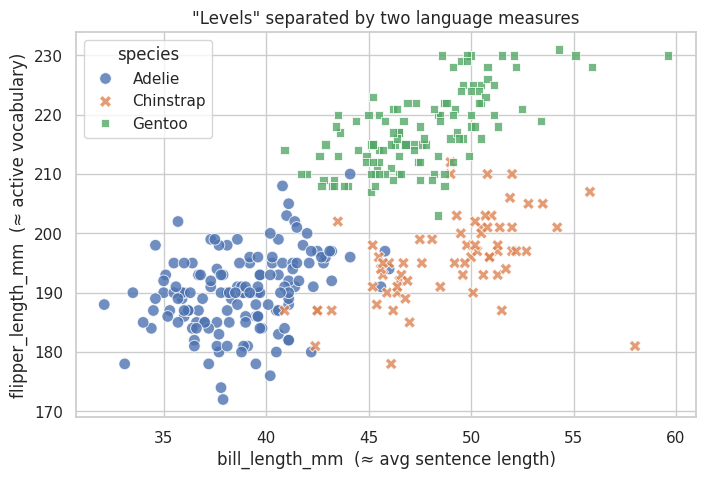

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=penguins, x="bill_length_mm", y="flipper_length_mm",
                hue="species", style="species", s=70, alpha=0.8, ax=ax)
ax.set_title('"Levels" separated by two language measures')
ax.set_xlabel("bill_length_mm  (≈ avg sentence length)")
ax.set_ylabel("flipper_length_mm  (≈ active vocabulary)")
plt.show()

**Pergunta 2:** Como se distribui o "escore de proficiência" (`body_mass_g`) em cada nível? Há
sobreposição entre eles?

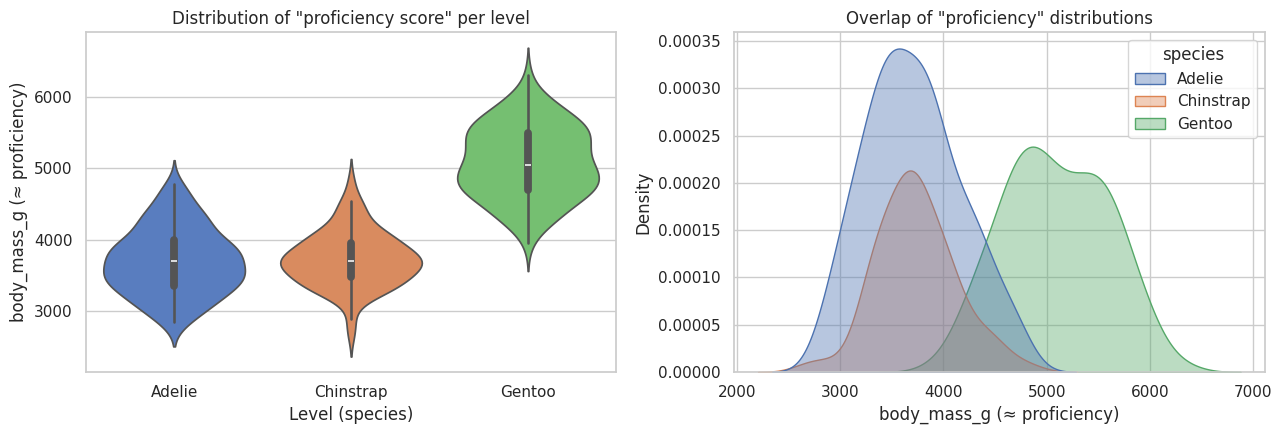

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: violin plot of the "proficiency score" per level
sns.violinplot(data=penguins, x="species", y="body_mass_g",
               hue="species", palette="muted", legend=False, ax=axes[0])
axes[0].set_title('Distribution of "proficiency score" per level')
axes[0].set_xlabel("Level (species)")
axes[0].set_ylabel("body_mass_g (≈ proficiency)")

# Right: overlapping KDEs make the overlap explicit
sns.kdeplot(data=penguins, x="body_mass_g", hue="species",
            fill=True, alpha=0.4, ax=axes[1])
axes[1].set_title('Overlap of "proficiency" distributions')
axes[1].set_xlabel("body_mass_g (≈ proficiency)")

fig.tight_layout()
plt.show()

**Pergunta 3:** Qual a força das relações entre todas as medidas numéricas? (matriz de correlação)

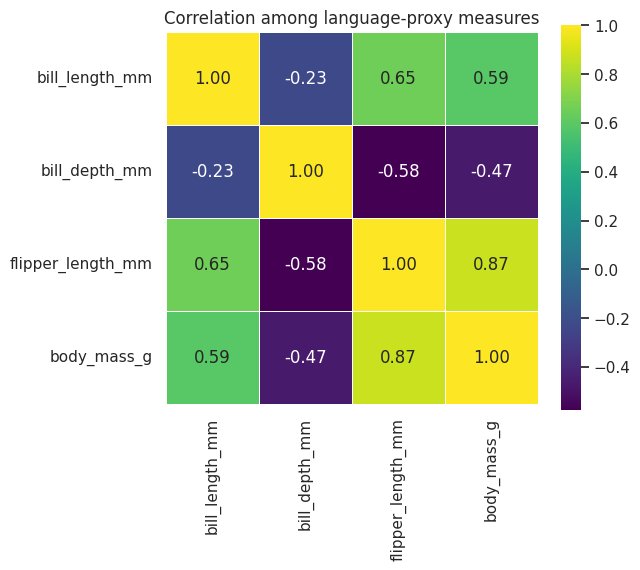

In [25]:
num_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
corr = penguins[num_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="viridis", fmt=".2f",
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation among language-proxy measures")
plt.show()

### 📌 Interpretação (conclusões do estudo de caso)

- Os "níveis" (`species`) formam **clusters visualmente separáveis** no scatter — o que, num contexto
  educacional, sugeriria que as duas métricas conseguem *discriminar* estágios de aprendizagem.
- As distribuições de "proficiência" **se sobrepõem parcialmente**: nenhuma métrica isolada separa
  perfeitamente os grupos — reforçando a importância de usar **múltiplas variáveis**.
- A correlação forte entre `flipper_length_mm` e `body_mass_g` mostra como escolher variáveis
  **redundantes** pode enviesar uma análise — um cuidado essencial em *feature engineering*.

## ✅ Resumo & Próximos Passos

### O que praticamos hoje

| Tópico | Ferramenta principal |
|--------|----------------------|
| Figuras, eixos, subplots | `plt.subplots` |
| Linha, barra, scatter, histograma | Matplotlib |
| Temas, `hue`/`size`/`style`, regressão | Seaborn (nível de eixo) |
| Boxplot, violin, heatmap, pairplot | Seaborn estatístico |
| Countplot, barplot | Seaborn categórico |
| Combinar camadas mpl + sns | `ax` compartilhado |
| Customização e anotações | `annotate`, paletas, `despine` |
| Salvar figuras | `fig.savefig(dpi=300)` |

### Boas práticas que ficam

1. Prefira a **interface orientada a objetos** (`fig, ax = plt.subplots()`).
2. **Sempre** rotule eixos e dê um título — um gráfico sem contexto não comunica.
3. Escolha o **tipo de gráfico certo** para a pergunta (distribuição → histograma/box/violin;
   relação → scatter; comparação → barra).
4. Use **cor com propósito** (categórica × sequencial × divergente), não decoração.

### Próximos passos (Dia 4 →)

- Aprofundar em **Análise Exploratória de Dados (EDA)** combinando Pandas + visualização.
- Aplicar estas técnicas a um **corpus textual real** dentro da trilha de **NLP**.
- Explorar visualização interativa (Plotly) em fases mais avançadas.

---
*Notebook do portfólio de Data Science — Dia 3 / Fase 1. Todos os dados são reais e públicos
(datasets embutidos do Seaborn). Código e comentários em inglês; notas de aprendizado em português.*